In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

url = "https://huggingface.co/datasets/winvoker/turkish-sentiment-analysis-dataset/resolve/main/test.csv"
df = pd.read_csv(url)
df = df[df["label"] != "Notr"].copy()
df["etiket"] = df["label"].map({"Positive": 1, "Negative": 0})

# Klasik modelle AYNI bölme (adil karşılaştırma için)
train_df, test_df = train_test_split(
    df[["text", "etiket"]], test_size=0.2,
    random_state=42, stratify=df["etiket"]
)

print("Eğitim:", train_df.shape)
print("Test:", test_df.shape)
print("\nEğitim sınıf dağılımı:")
print(train_df["etiket"].value_counts())

Eğitim: (25498, 2)
Test: (6375, 2)

Eğitim sınıf dağılımı:
etiket
1    20973
0     4525
Name: count, dtype: int64


In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_adi = "dbmdz/bert-base-turkish-cased"
tokenizer = AutoTokenizer.from_pretrained(model_adi)
model = AutoModelForSequenceClassification.from_pretrained(model_adi, num_labels=2)
print("Model ve tokenizer yüklendi.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/251k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model ve tokenizer yüklendi.


In [4]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True,
                     padding="max_length", max_length=128)

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

# Trainer'ın beklediği isim: "labels"
train_ds = train_ds.rename_column("etiket", "labels")
test_ds = test_ds.rename_column("etiket", "labels")

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Tokenizasyon tamam.")
print("Bir örnek anahtarları:", list(train_ds[0].keys()))

Map:   0%|          | 0/25498 [00:00<?, ? examples/s]

Map:   0%|          | 0/6375 [00:00<?, ? examples/s]

Tokenizasyon tamam.
Bir örnek anahtarları: ['labels', 'input_ids', 'attention_mask']


In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def metrikler(pred):
    etiketler = pred.label_ids
    tahminler = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(etiketler, tahminler),
        "f1_negative": f1_score(etiketler, tahminler, pos_label=0),
        "f1_macro": f1_score(etiketler, tahminler, average="macro"),
    }

In [8]:
from transformers import TrainingArguments, Trainer

args = TrainingArguments(
    output_dir="sonuclar",
    num_train_epochs=2,                  # veriyi 2 kez gez
    per_device_train_batch_size=16,      # bir seferde 16 yorum
    per_device_eval_batch_size=32,
    eval_strategy="epoch",               # her epoch sonunda ölç
    logging_steps=200,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=metrikler,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Negative,F1 Macro
1,0.183433,0.203121,0.945882,0.832443,0.900086
2,0.091337,0.188933,0.949804,0.851024,0.910421


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3188, training_loss=0.15388849837567606, metrics={'train_runtime': 1426.0813, 'train_samples_per_second': 35.76, 'train_steps_per_second': 2.235, 'total_flos': 3354402844784640.0, 'train_loss': 0.15388849837567606, 'epoch': 2.0})

In [9]:
from transformers import pipeline

fine = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0)

test_cumleler = [
    "bu ürün gerçekten harika çok memnun kaldım",
    "berbat bir deneyim asla tavsiye etmem",
    "çok yavaş kargo",
    "kutudan kırık çıktı",
    "ürün güzel ama kargo berbat asla almayın",
]

print("--- Fine-tuned model ---")
for c in test_cumleler:
    r = fine(c)[0]
    etiket = "Olumlu" if r["label"].endswith("1") else "Olumsuz"
    print(f"{etiket} (%{r['score']*100:.0f})  ←  {c}")

--- Fine-tuned model ---
Olumlu (%100)  ←  bu ürün gerçekten harika çok memnun kaldım
Olumsuz (%100)  ←  berbat bir deneyim asla tavsiye etmem
Olumsuz (%95)  ←  çok yavaş kargo
Olumsuz (%98)  ←  kutudan kırık çıktı
Olumsuz (%99)  ←  ürün güzel ama kargo berbat asla almayın


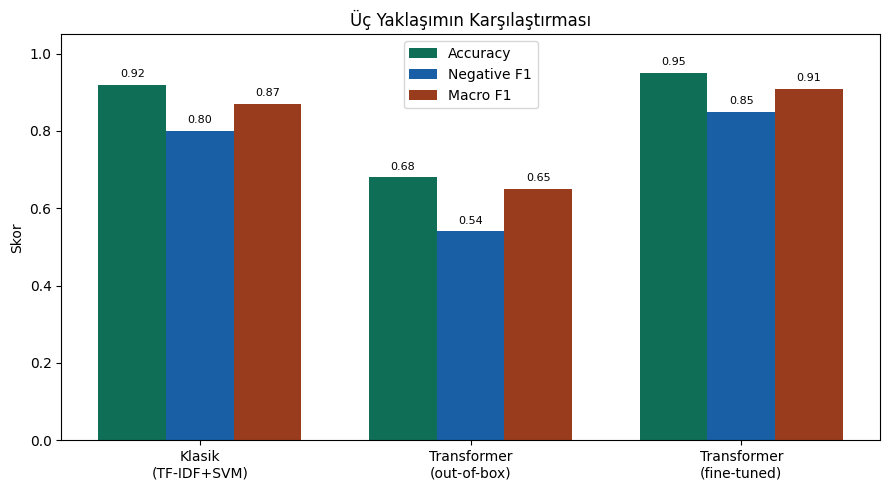

In [10]:
import matplotlib.pyplot as plt
import numpy as np

modeller = ["Klasik\n(TF-IDF+SVM)", "Transformer\n(out-of-box)", "Transformer\n(fine-tuned)"]
accuracy = [0.92, 0.68, 0.95]
neg_f1   = [0.80, 0.54, 0.85]
macro_f1 = [0.87, 0.65, 0.91]

x = np.arange(len(modeller)); w = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w, accuracy, w, label="Accuracy", color="#0f6e56")
ax.bar(x,     neg_f1,   w, label="Negative F1", color="#185fa5")
ax.bar(x + w, macro_f1, w, label="Macro F1", color="#993c1d")
ax.set_xticks(x); ax.set_xticklabels(modeller); ax.set_ylim(0, 1.05)
ax.set_ylabel("Skor"); ax.set_title("Üç Yaklaşımın Karşılaştırması")
ax.legend()
for i in range(len(modeller)):
    ax.text(x[i]-w, accuracy[i]+0.02, f"{accuracy[i]:.2f}", ha="center", fontsize=8)
    ax.text(x[i],   neg_f1[i]+0.02,   f"{neg_f1[i]:.2f}",   ha="center", fontsize=8)
    ax.text(x[i]+w, macro_f1[i]+0.02, f"{macro_f1[i]:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("uc_model_karsilastirma.png", dpi=120, bbox_inches="tight")
plt.show()

In [11]:
from google.colab import files
files.download("uc_model_karsilastirma.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>